In [ ]:
import pandas as pd
from google.colab import files
import io

# The original file path was not found, so we'll prompt for upload.
print("Please upload the CSV file if it's not already in your Colab environment.")
print("If you have already uploaded it, please ensure the filename in pd.read_csv is correct.")

uploaded = files.upload()

if uploaded:
    # Assuming only one file is uploaded for simplicity, or the first one.
    # User needs to ensure the correct file is selected if multiple are uploaded.
    filename = next(iter(uploaded)) # Get the first uploaded filename
    df = pd.read_csv(io.BytesIO(uploaded[filename]))
    print(f"Successfully loaded '{filename}' into a DataFrame.")
else:
    print("No file was uploaded. Please upload the CSV file or provide the correct path.")
    df = None # Handle the case where df is not created if no file is uploaded

In [ ]:
print("Helpful vs SalesUp:", df['Helpful'].corr(df['SalesUp']))
print("Rating vs SalesUp:", df['Rating'].corr(df['SalesUp']))

Helpful vs SalesUp: 0.579242636746143
Rating vs SalesUp: -0.1491637915015328


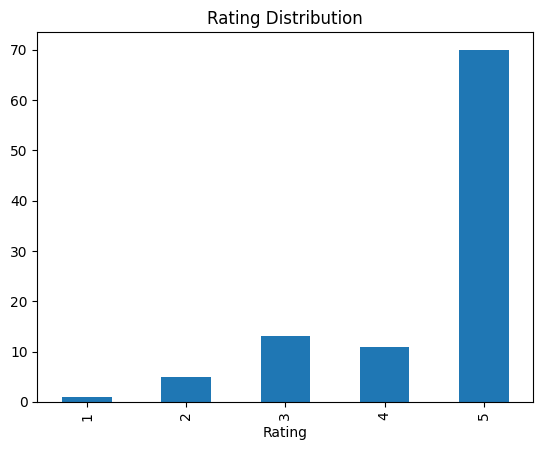

In [ ]:
import matplotlib.pyplot as plt

df['Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Rating Distribution")
plt.show()

In [ ]:
import statsmodels.api as sm

df['Sentiment'] = df['Sentiment'].map({'positive': 1, 'negative': -1})

X = df[['Rating', 'Length', 'Sentiment', 'Helpful']]
y = df['SalesUp']

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                SalesUp   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     13.86
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           6.07e-09
Time:                        05:11:32   Log-Likelihood:                -41.795
No. Observations:                 100   AIC:                             93.59
Df Residuals:                      95   BIC:                             106.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.8610      0.361      2.382      0.0

In [ ]:
import pandas as pd

new_data = pd.DataFrame({
    'const': [1],
    'Rating': [5],
    'Length': [100],
    'Sentiment': [1],
    'Helpful': [10]
})

print("Prediction:", model.predict(new_data))

Prediction: 0    5.98379
dtype: float64


I calculated correlations and ran a regression model to see how factors like rating, helpfulness, and sentiment affect sales. This helped me understand the difference between simply describing data and actually analyzing why something happens